# Análisis Exploratorio de Datos

**Objetivo:** Realizar un análisis exploratorio y visual sobre los datasets integrados y limpios.

## 0. Carga de librerías y definición de rutas

In [1]:
# Librerias
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from collections import Counter, defaultdict

In [2]:
# Rutas a los datasets procesados
ruta_processed_global = '../data/processed/dataset_global'
ruta_processed_local  = '../data/processed/dataset_local'

# Diccionario: id -> nombre de clase
mapa_clases = {
    0: 'D20 (Piel de Cocodrilo)',
    1: 'D40 (Bache)',
    2: 'calle_tierra'
}

## 1. Volumen total

En esta primera etapa vamos a cuantificar el volumen total de instancias anotadas en cada dataset, desglosadas por clase. Esto nos permite evaluar si existe un desbalance de clases significativo antes de iniciar el entrenamiento.

Se entiende por **instancia** cada bounding box individual registrada dentro de un archivo `.txt` de anotaciones YOLO, siendo la unidad mínima de información que el modelo aprenderá a detectar.

In [3]:
def contar_instancias_por_clase(ruta_base, splits):
    contador = Counter()
    for split in splits:
        patron = os.path.join(ruta_base, split, 'labels', '*.txt')
        for ruta_txt in glob.glob(patron):
            with open(ruta_txt, 'r') as f:
                for linea in f:
                    linea = linea.strip()
                    if linea:
                        clase_id = int(linea.split()[0])
                        contador[clase_id] += 1
    return contador

instancias_global = contar_instancias_por_clase(ruta_processed_global, ['train', 'valid'])
instancias_local  = contar_instancias_por_clase(ruta_processed_local,  ['train', 'valid', 'test'])

print("--- Instancias por clase: Dataset Global (RDD2022) ---")
for cid, count in sorted(instancias_global.items()):
    print(f"  {mapa_clases.get(cid, cid)}: {count}")

print()
print("--- Instancias por clase: Dataset Local (Moreno) ---")
for cid, count in sorted(instancias_local.items()):
    print(f"  {mapa_clases.get(cid, cid)}: {count}")

--- Instancias por clase: Dataset Global (RDD2022) ---
  D20 (Piel de Cocodrilo): 9490
  D40 (Bache): 6323

--- Instancias por clase: Dataset Local (Moreno) ---
  D20 (Piel de Cocodrilo): 167
  D40 (Bache): 227
  calle_tierra: 413


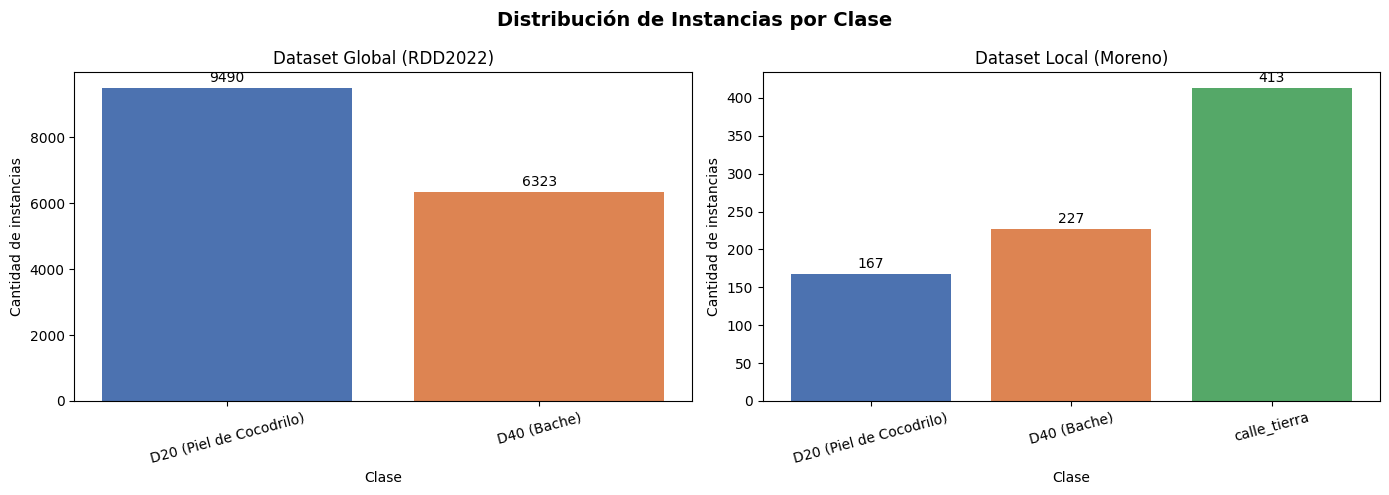

In [4]:
# Visualizacion comparativa de distribucion de instancias
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Instancias por Clase', fontsize=14, fontweight='bold')

colores_clases = ['#4C72B0', '#DD8452', '#55A868']

for ax, (contador, titulo) in zip(axes, [
    (instancias_global, 'Dataset Global (RDD2022)'),
    (instancias_local,  'Dataset Local (Moreno)')
]):
    clases = sorted(contador.keys())
    valores = [contador[c] for c in clases]
    etiquetas = [mapa_clases.get(c, str(c)) for c in clases]
    barras = ax.bar(etiquetas, valores, color=[colores_clases[c % len(colores_clases)] for c in clases])

    for barra, val in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + max(valores) * 0.01,
                str(val), ha='center', va='bottom', fontsize=10)

    ax.set_title(titulo)
    ax.set_ylabel('Cantidad de instancias')
    ax.set_xlabel('Clase')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

En primera instancia, notamos que el dataset global (RDD2022) posee una mayor cantidad de Grietas o Piel de Cocodrilo que de Baches (D40) en sí. Con respecto al Dataset Local se suma la instancia "Calle_tierra" la cual predomina en dicho dataset.

Más adelante en el Notebook 03 se volverán a utilizar estos valores totales para comparación.

## 2. Funciones auxiliares para análisis


Se definen funciones auxiliares para recorrer los directorios procesados, leer etiquetas YOLO, obtener metadatos básicos de las imágenes y consolidar toda la información en tablas de análisis.

In [5]:

def leer_etiqueta_yolo(ruta_txt):
    registros = []

    if not os.path.exists(ruta_txt):
        return registros

    with open(ruta_txt, "r", encoding="utf-8") as f:
        lineas = [linea.strip() for linea in f.readlines() if linea.strip()]

    for linea in lineas:
        partes = linea.split()
        if len(partes) != 5:
            continue

        clase, x_center, y_center, width, height = partes
        clase = int(float(clase))
        x_center = float(x_center)
        y_center = float(y_center)
        width = float(width)
        height = float(height)

        registros.append({
            "clase_id": clase,
            "clase_nombre": mapa_clases.get(clase, f"desconocida_{clase}"),
            "x_center": x_center,
            "y_center": y_center,
            "bbox_width": width,
            "bbox_height": height,
            "bbox_area": width * height,
            "aspect_ratio": width / height if height > 0 else np.nan
        })

    return registros


def construir_dataframe_dataset(ruta_dataset, nombre_dataset):
    registros_imagenes = []
    registros_boxes = []

    divisiones = ["train", "valid", "test"]

    for division in divisiones:
        ruta_imagenes = os.path.join(ruta_dataset, division, "images")
        ruta_labels = os.path.join(ruta_dataset, division, "labels")

        if not os.path.exists(ruta_imagenes):
            continue

        extensiones = ("*.jpg", "*.jpeg", "*.png")
        archivos_imagen = []
        for ext in extensiones:
            archivos_imagen.extend(glob.glob(os.path.join(ruta_imagenes, ext)))

        for ruta_imagen in archivos_imagen:
            nombre_archivo = os.path.splitext(os.path.basename(ruta_imagen))[0]
            ruta_txt = os.path.join(ruta_labels, nombre_archivo + ".txt")

            imagen = cv2.imread(ruta_imagen)
            if imagen is None:
                continue

            alto, ancho = imagen.shape[:2]
            boxes = leer_etiqueta_yolo(ruta_txt)

            registros_imagenes.append({
                "dataset": nombre_dataset,
                "split": division,
                "imagen_id": nombre_archivo,
                "ruta_imagen": ruta_imagen,
                "ruta_label": ruta_txt,
                "ancho_px": ancho,
                "alto_px": alto,
                "resolucion_px": ancho * alto,
                "cantidad_boxes": len(boxes),
                "tiene_objetos": len(boxes) > 0
            })

            for idx, box in enumerate(boxes, start=1):
                registros_boxes.append({
                    "dataset": nombre_dataset,
                    "split": division,
                    "imagen_id": nombre_archivo,
                    "box_id": idx,
                    **box
                })

    df_imagenes = pd.DataFrame(registros_imagenes)
    df_boxes = pd.DataFrame(registros_boxes)

    return df_imagenes, df_boxes

## 3. Carga de metadatos

In [6]:
df_img_global, df_box_global = construir_dataframe_dataset(ruta_processed_global, "global")
df_img_local, df_box_local = construir_dataframe_dataset(ruta_processed_local, "local")

df_imagenes = pd.concat([df_img_global, df_img_local], ignore_index=True)
df_boxes = pd.concat([df_box_global, df_box_local], ignore_index=True)

print("--- Resumen general de carga ---")
print(f"Imagenes procesadas: {len(df_imagenes):,}")
print(f"Bounding boxes totales: {len(df_boxes):,}")

print(df_imagenes.groupby(['dataset', 'split']).size().rename('imagenes'))

--- Resumen general de carga ---
Imagenes procesadas: 33,082
Bounding boxes totales: 16,620
dataset  split
global   train    28061
         valid     3118
local    test        79
         train     1665
         valid      159
Name: imagenes, dtype: int64


Se invoca la función construir_dataframe_dataset() sobre ambos datasets procesados para materializar toda la información dispersa en archivos en dos DataFrames centrales:

df_imagenes (una fila por imagen, con sus dimensiones reales y cantidad de objetos anotados)

df_boxes (una fila por bounding box, con sus coordenadas normalizadas y métricas geométricas derivadas).

## 4. Volumen estructural del dataset

Se resume el volumen final de datos por fuente y partición. Esto permite verificar si la integración previa dejó un conjunto consistente y, además, si la distribución entre `train`, `valid` y `test` resulta coherente con el diseño experimental.

In [7]:

resumen_estructural = (
    df_imagenes
    .groupby(["dataset", "split"])
    .agg(
        imagenes=("imagen_id", "count"),
        imagenes_con_objetos=("tiene_objetos", "sum"),
        imagenes_sin_objetos=("tiene_objetos", lambda x: (~x).sum()),
        promedio_boxes=("cantidad_boxes", "mean")
    )
    .reset_index()
)

resumen_estructural

,dataset,split,imagenes,imagenes_con_objetos,imagenes_sin_objetos,promedio_boxes
0,global,train,28061,8454,19607,0.507466
1,global,valid,3118,942,2176,0.504490
2,local,test,79,22,57,0.291139
3,local,train,1665,585,1080,0.423423
4,local,valid,159,55,104,0.496855


Se construye una tabla resumen que cruza fuente (global/local) con partición (train/valid/test), exponiendo cuatro métricas clave por combinación: el total de imágenes, cuántas tienen al menos un daño anotado (imagenes_con_objetos), cuántas son imágenes de fondo sin anotaciones (imagenes_sin_objetos) y el promedio de bounding boxes por imagen (promedio_boxes).
Del resultado se desprenden dos observaciones importantes: el dataset global presenta una proporción llamativamente alta de imágenes sin objetos, lo cual es esperable dado que el RDD2022 incluye tramos de calles en buen estado que actúan como negativos de entrenamiento. El dataset local, en cambio, tiene una densidad de anotaciones más baja en términos absolutos pero una proporción de imágenes positivas más equilibrada.

## 5. Distribución de clases

En este proyecto interesan tres clases finales:

* `D20`: grietas / fisuras longitudinales o transversales (Piel de cocodrilo)
* `D40`: baches
* `calle_tierra`: superficie no asfaltada

In [8]:
distribucion_clases = (
    df_boxes
    .groupby(["dataset", "split", "clase_nombre"])
    .size()
    .rename("cantidad_boxes")
    .reset_index()
)

distribucion_clases.sort_values(["dataset", "split", "cantidad_boxes"], ascending=[True, True, False])

,dataset,split,clase_nombre,cantidad_boxes
0,global,train,D20 (Piel de Cocodrilo),8554
1,global,train,D40 (Bache),5686
2,global,valid,D20 (Piel de Cocodrilo),936
3,global,valid,D40 (Bache),637
6,local,test,calle_tierra,19
4,local,test,D20 (Piel de Cocodrilo),2
5,local,test,D40 (Bache),2
9,local,train,calle_tierra,363
8,local,train,D40 (Bache),204
7,local,train,D20 (Piel de Cocodrilo),138


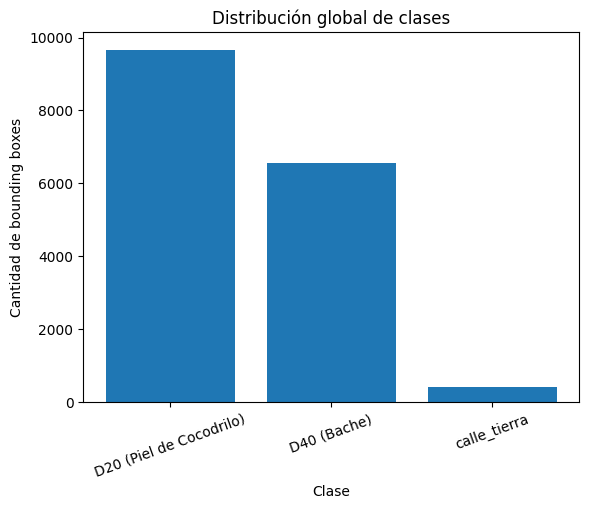

In [9]:
conteo_total_clases = (
    df_boxes["clase_nombre"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure()
plt.bar(conteo_total_clases.index, conteo_total_clases.values)
plt.title("Distribución global de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad de bounding boxes")
plt.xticks(rotation=20)
plt.show()

In [10]:
tabla_proporciones = (

    df_boxes["clase_nombre"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("porcentaje")
    .reset_index()
    .rename(columns={"index": "clase"})
)

tabla_proporciones

,clase_nombre,porcentaje
0,D20 (Piel de Cocodrilo),58.10
1,D40 (Bache),39.41
2,calle_tierra,2.48


## 6. Cargas por imagen

Además de contar clases, observamos cuántas cajas tiene cada imagen.

Este análisis ayuda a detectar si el modelo se entrenará mayormente sobre escenas simples (un daño por imagen) o escenas complejas (múltiples daños simultáneos)

In [11]:
df_imagenes["cantidad_boxes"].describe()

count    33082.000000
mean         0.502388
std          0.991062
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         13.000000
Name: cantidad_boxes, dtype: float64

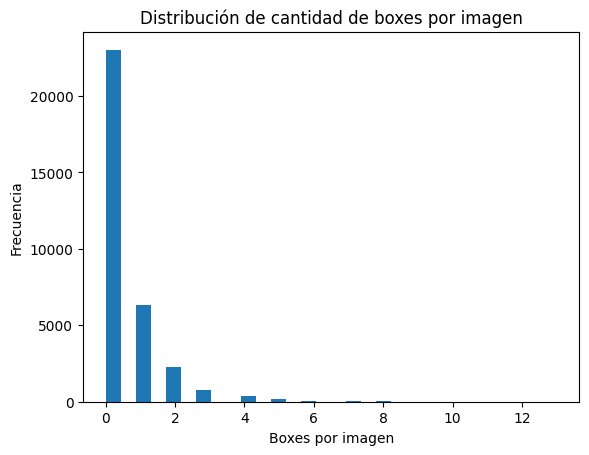

In [12]:

plt.figure()
plt.hist(df_imagenes["cantidad_boxes"], bins=30)
plt.title("Distribución de cantidad de boxes por imagen")
plt.xlabel("Boxes por imagen")
plt.ylabel("Frecuencia")
plt.show()

In [13]:

imagenes_mas_cargadas = (
    df_imagenes
    .sort_values("cantidad_boxes", ascending=False)
    [["dataset", "split", "imagen_id", "cantidad_boxes", "ancho_px", "alto_px"]]
    .head(10)
)

imagenes_mas_cargadas

,dataset,split,imagen_id,cantidad_boxes,ancho_px,alto_px
10561,global,train,India_008860,13,720,720
8403,global,train,India_005781,13,720,720
25115,global,train,Norway_004891,12,3650,2044
6306,global,train,India_002793,12,720,720
24109,global,train,Norway_003780,11,3650,2044
6861,global,train,India_003565,11,720,720
5298,global,train,India_001381,10,720,720
5635,global,train,India_001852,10,720,720
22206,global,train,Norway_001666,10,3650,2044
21452,global,train,Norway_000833,10,4040,2035


Los resultados revelan una distribución fuertemente sesgada hacia la izquierda: la mediana es 0 y la media es apenas 0.50 boxes por imagen, lo que confirma que la mayoría de las imágenes sin daños.

Los negativos de entrenamiento son necesarios para que el modelo aprenda a no generar falsas detecciones en superficies sanas como asfaltos o autopistas.

Entre las imágenes que sí tienen detecciones, la mayoría presenta entre 1 y 3 boxes, lo cual corresponde a escenas con daños aislados o puntuales. Las imágenes con 10 o más boxes (visibles en la parte derecha del histograma) provienen casi en su totalidad del dataset global, particularmente de India y Noruega (Norway, en el dataset) donde las capturas muestran tramos con muchos deterioros.

## 7. Geometría de las "cajas" (Bounding Boxes)


En detección de objetos no solo importa qué clases existen, sino también cómo son geométricamente las cajas. Las cajas extremadamente pequeñas pueden ser difíciles de detectar; las muy alargadas pueden sugerir errores de normalizaciónn.

In [14]:

df_boxes[["bbox_width", "bbox_height", "bbox_area", "aspect_ratio"]].describe()

,bbox_width,bbox_height,bbox_area,aspect_ratio
count,16620.000000,16620.000000,16620.000000,16620.000000
mean,0.295768,0.186536,0.080658,1.766300
std,0.249266,0.150828,0.111864,0.991557
min,0.000000,0.001667,0.000000,0.000000
25%,0.100000,0.063333,0.006509,1.077288
50%,0.211667,0.148438,0.033070,1.538456
75%,0.420000,0.270353,0.115344,2.224609
max,0.999023,0.996094,0.940847,12.744731


In [15]:

outliers_boxes = df_boxes[
    (df_boxes["bbox_area"] > df_boxes["bbox_area"].quantile(0.99)) |
    (df_boxes["bbox_area"] < df_boxes["bbox_area"].quantile(0.01))
]

outliers_boxes[["dataset", "split", "imagen_id", "clase_nombre", "bbox_width", "bbox_height", "bbox_area", "aspect_ratio"]].head(15)

,dataset,split,imagen_id,clase_nombre,bbox_width,bbox_height,bbox_area,aspect_ratio
25,global,train,China_MotorBike_000075,D20 (Piel de Cocodrilo),0.833984,0.626953,0.522869,1.330218
35,global,train,China_MotorBike_000091,D40 (Bache),0.011719,0.017578,0.000206,0.666686
41,global,train,China_MotorBike_000105,D20 (Piel de Cocodrilo),0.875000,0.646484,0.565673,1.353475
51,global,train,China_MotorBike_000125,D20 (Piel de Cocodrilo),0.873047,0.605469,0.528603,1.441935
54,global,train,China_MotorBike_000135,D20 (Piel de Cocodrilo),0.998047,0.662109,0.660816,1.507376
89,global,train,China_MotorBike_000215,D20 (Piel de Cocodrilo),0.998047,0.542969,0.541909,1.838129
97,global,train,China_MotorBike_000228,D20 (Piel de Cocodrilo),0.847656,0.945312,0.801299,0.896694
101,global,train,China_MotorBike_000250,D20 (Piel de Cocodrilo),0.998047,0.648438,0.647172,1.539156
122,global,train,China_MotorBike_000325,D20 (Piel de Cocodrilo),0.998047,0.814453,0.812862,1.225420
131,global,train,China_MotorBike_000340,D20 (Piel de Cocodrilo),0.578125,0.996094,0.575867,0.580392


El ancho promedio (0.296) es considerablemente mayor que el alto promedio (0.187), lo que indica que los daños tienden a ser más anchos que altos en el encuadre, consistente con la perspectiva desde el tablero del vehículo.

El aspect ratio promedio de 1.77 confirma este patrón: las cajas son en promedio casi el doble de anchas que altas.

El área mediana es de apenas 0.033, es decir que la caja típica ocupa solo el 3.3% del área total de la imagen. Esto clasifica el problema como detección de objetos pequeños a medianos.

## 8. Comparación entre dataset global y dataset local

Contrastamos con el dataset global y observar si ambos aportan contextos complementarios o si existe una brecha importante entre ellos.

In [16]:

comparacion_fuentes = pd.DataFrame({
    "imagenes": df_imagenes.groupby("dataset").size(),
    "boxes": df_boxes.groupby("dataset").size(),
    "promedio_boxes_por_imagen": df_imagenes.groupby("dataset")["cantidad_boxes"].mean()
}).round(2)

comparacion_fuentes

,imagenes,boxes,promedio_boxes_por_imagen
dataset,,,
global,31179,15813,0.51
local,1903,807,0.42


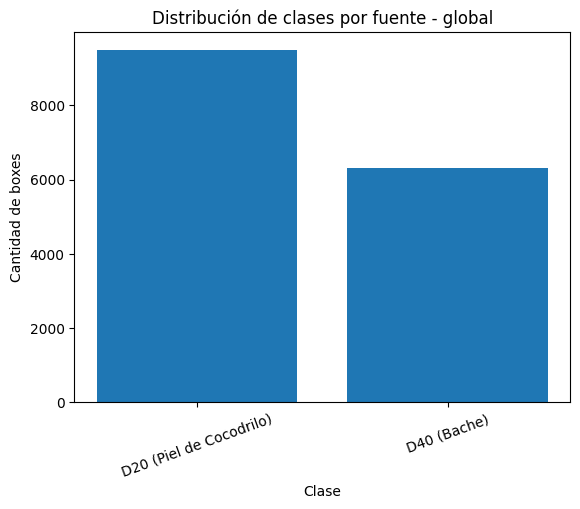

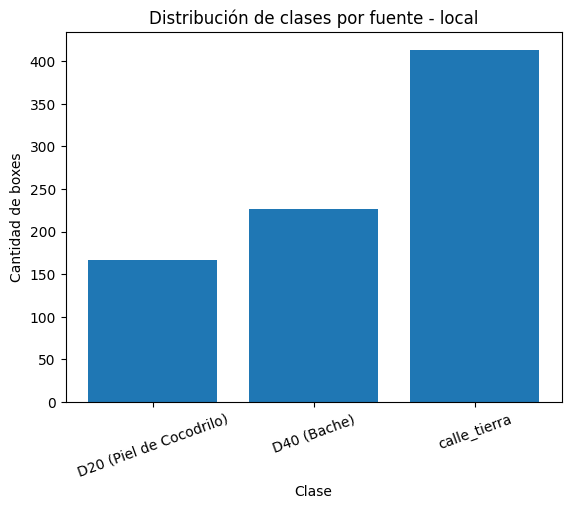

In [17]:

comparacion_clases_fuente = (
    df_boxes
    .groupby(["dataset", "clase_nombre"])
    .size()
    .rename("cantidad")
    .reset_index()
)

for dataset in comparacion_clases_fuente["dataset"].unique():
    subset = comparacion_clases_fuente[comparacion_clases_fuente["dataset"] == dataset]

    plt.figure()
    plt.bar(subset["clase_nombre"], subset["cantidad"])
    plt.title(f"Distribución de clases por fuente - {dataset}")
    plt.xlabel("Clase")
    plt.ylabel("Cantidad de boxes")
    plt.xticks(rotation=20)
    plt.show()

Volumen: El dataset global aporta aproximadamente 16 veces más imágenes que el local (31.170 vs 1.903).

Densidad de anotaciones: Ambos datasets tienen un promedio de boxes por imagen similar y bajo (0.51 global, 0.42 local), confirmando que la mayoría de las imágenes son de fondo en los dos casos.

El dataset global solo contiene D20 y D40, con predominio de D20.

El dataset local incorpora además calle_tierra como clase mayoritaria, una categoría inexistente en el RDD2022 ya que este representa una realidad específica del municipio de Moreno.

## 9. Inspección visual

Se visualizan algunas imágenes junto con sus cajas para complementar el análisis cuantitativo.

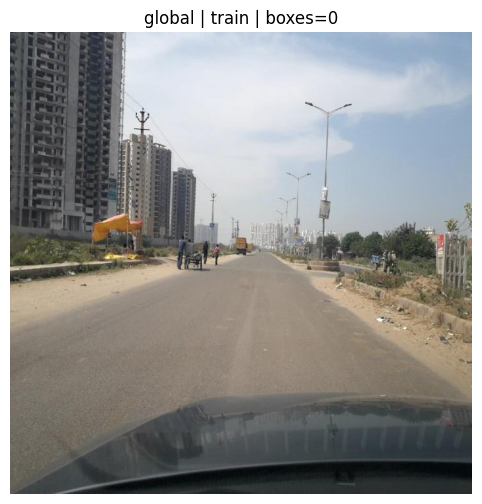

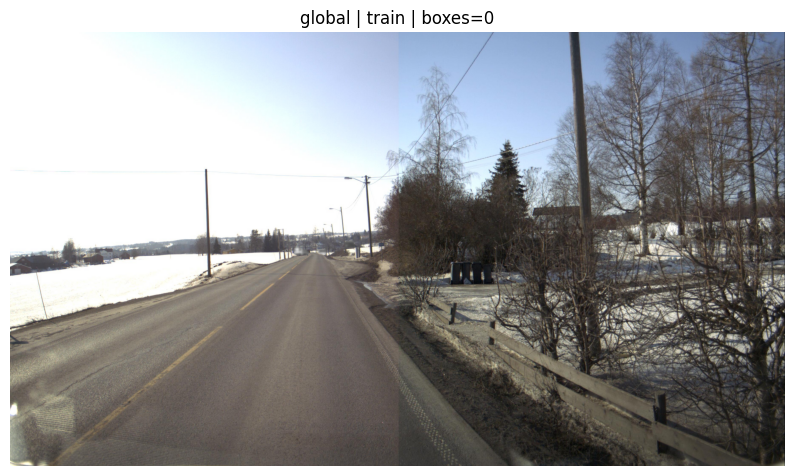

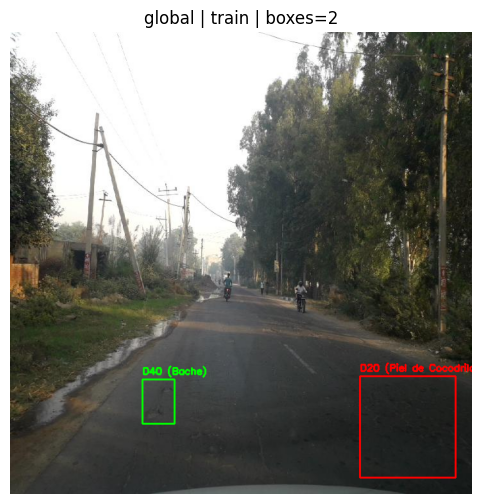

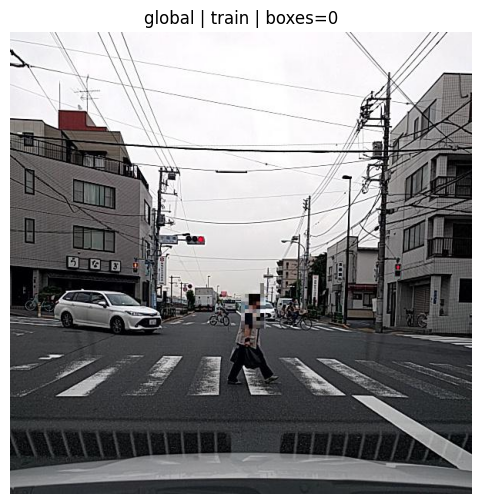

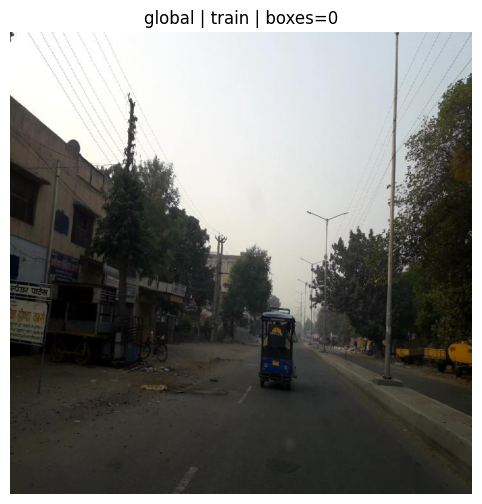

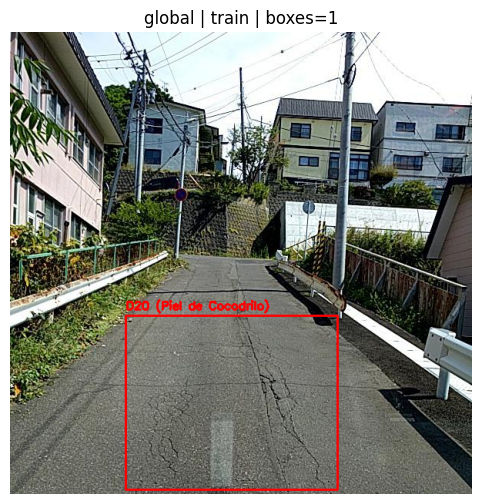

In [18]:

colores = {
    0: (255, 0, 0),
    1: (0, 255, 0),
    2: (0, 0, 255)
}

def visualizar_muestra(ruta_imagen, ruta_txt, titulo=None):
    imagen = cv2.imread(ruta_imagen)
    if imagen is None:
        print(f"No se pudo leer: {ruta_imagen}")
        return

    imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    alto, ancho = imagen.shape[:2]

    if os.path.exists(ruta_txt):
        with open(ruta_txt, "r", encoding="utf-8") as f:
            lineas = [l.strip() for l in f.readlines() if l.strip()]

        for linea in lineas:
            clase, xc, yc, w, h = map(float, linea.split())
            clase = int(clase)

            x1 = int((xc - w / 2) * ancho)
            y1 = int((yc - h / 2) * alto)
            x2 = int((xc + w / 2) * ancho)
            y2 = int((yc + h / 2) * alto)

            color = colores.get(clase, (255, 255, 0))
            cv2.rectangle(imagen, (x1, y1), (x2, y2), color, 2)
            cv2.putText(
                imagen,
                mapa_clases.get(clase, str(clase)),
                (x1, max(y1 - 8, 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                color,
                2
            )

    plt.figure(figsize=(10, 6))
    plt.imshow(imagen)
    plt.title(titulo if titulo else os.path.basename(ruta_imagen))
    plt.axis("off")
    plt.show()


muestras = df_imagenes.sample(min(6, len(df_imagenes)), random_state=42)

for _, fila in muestras.iterrows():
    visualizar_muestra(
        fila["ruta_imagen"],
        fila["ruta_label"],
        titulo=f"{fila['dataset']} | {fila['split']} | boxes={fila['cantidad_boxes']}"
    )

## 10. Análisis de Desbalance de Clases

El desbalance entre clases es uno de los problemas más frecuentes en datasets de detección de objetos. Cuando una clase tiene muchas más instancias que otra, el modelo tiende a optimizar su rendimiento detectando siempre la clase dominante, a costa de ignorar las minoritarias.


In [19]:
def calcular_proporciones(contador):
    total = sum(contador.values())
    return {cid: round(count / total * 100, 2) for cid, count in contador.items()}

# Conteo de instancias por clase directamente desde los DataFrames del principal
instancias_global = dict(df_box_global['clase_id'].value_counts().sort_index())
instancias_local  = dict(df_box_local['clase_id'].value_counts().sort_index())

prop_global = calcular_proporciones(instancias_global)
prop_local  = calcular_proporciones(instancias_local)

print('--- Proporcion relativa: Dataset Global (RDD2022) ---')
for cid, prop in sorted(prop_global.items()):
    print(f'  {mapa_clases.get(cid, cid)}: {prop}%')

print()
print('--- Proporcion relativa: Dataset Local (Moreno) ---')
for cid, prop in sorted(prop_local.items()):
    print(f'  {mapa_clases.get(cid, cid)}: {prop}%')

--- Proporcion relativa: Dataset Global (RDD2022) ---
  D20 (Piel de Cocodrilo): 60.01%
  D40 (Bache): 39.99%

--- Proporcion relativa: Dataset Local (Moreno) ---
  D20 (Piel de Cocodrilo): 20.69%
  D40 (Bache): 28.13%
  calle_tierra: 51.18%


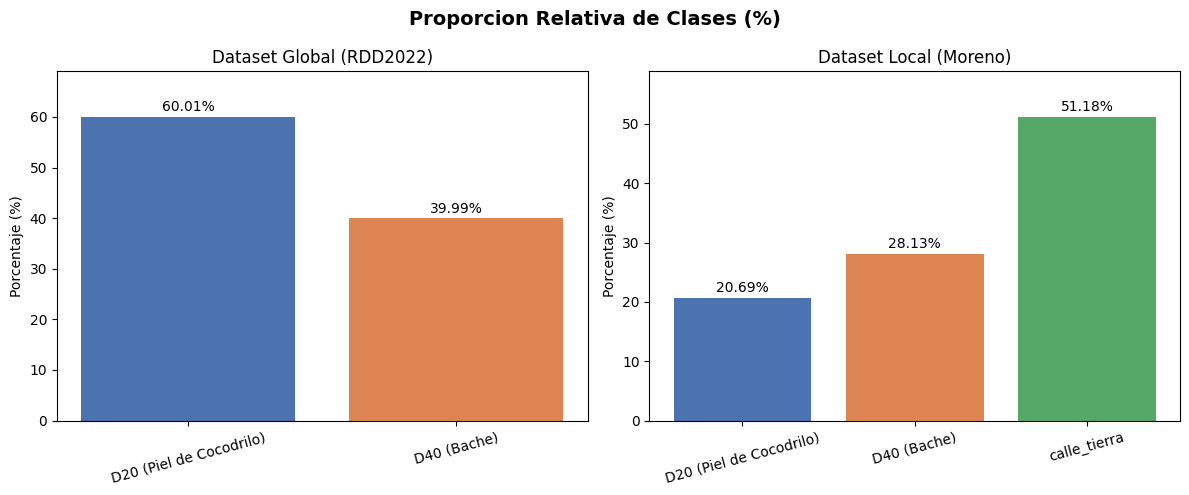

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Proporcion Relativa de Clases (%)', fontsize=14, fontweight='bold')

for ax, (proporciones, titulo) in zip(axes, [
    (prop_global, 'Dataset Global (RDD2022)'),
    (prop_local,  'Dataset Local (Moreno)')
]):
    clases    = sorted(proporciones.keys())
    valores   = [proporciones[c] for c in clases]
    etiquetas = [mapa_clases.get(c, str(c)) for c in clases]
    barras = ax.bar(etiquetas, valores, color=[colores_clases[c % len(colores_clases)] for c in clases])
    for barra, val in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 0.5,
                f'{val}%', ha='center', va='bottom', fontsize=10)
    ax.set_title(titulo)
    ax.set_ylabel('Porcentaje (%)')
    ax.set_ylim(0, max(valores) * 1.15)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


Dataset Global (RDD2022): Solo contiene las clases D20 y D40, con una distribución relativamente equilibrada (60% / 40%). Esto es esperable dado el filtrado aplicado en el Notebook 02, que descartó todas las clases fuera del alcance del proyecto.

Dataset Local (Moreno): La clase dominante es calle_tierra (51%), lo cual refleja la realidad del municipio: una parte significativa de las calles de Moreno no están pavimentadas. Las clases de daño (D20 y D40) representan en conjunto el 49% restante, con una leve ventaja para D40.

## 11. Distribución del Split Train / Validation / Test

Se verifica la distribución de imágenes entre particiones para confirmar que el split definido en el Notebook 02 se aplicó correctamente y que cada partición cuenta con suficiente representatividad estadística.

In [21]:
# Derivamos los conteos por split directamente desde los DataFrames ya cargados
splits_global = dict(df_img_global.groupby('split').size())
splits_local  = dict(df_img_local.groupby('split').size())

print('--- Distribucion de Imagenes: Dataset Global (RDD2022) ---')
total_global = sum(splits_global.values())
for split, cant in splits_global.items():
    print(f'  {split}: {cant} imagenes ({cant / total_global * 100:.1f}%)')
print(f'  TOTAL: {total_global}')

print()
print('--- Distribucion de Imagenes: Dataset Local (Moreno) ---')
total_local = sum(splits_local.values())
for split, cant in splits_local.items():
    print(f'  {split}: {cant} imagenes ({cant / total_local * 100:.1f}%)')
print(f'  TOTAL: {total_local}')

--- Distribucion de Imagenes: Dataset Global (RDD2022) ---
  train: 28061 imagenes (90.0%)
  valid: 3118 imagenes (10.0%)
  TOTAL: 31179

--- Distribucion de Imagenes: Dataset Local (Moreno) ---
  test: 79 imagenes (4.2%)
  train: 1665 imagenes (87.5%)
  valid: 159 imagenes (8.4%)
  TOTAL: 1903


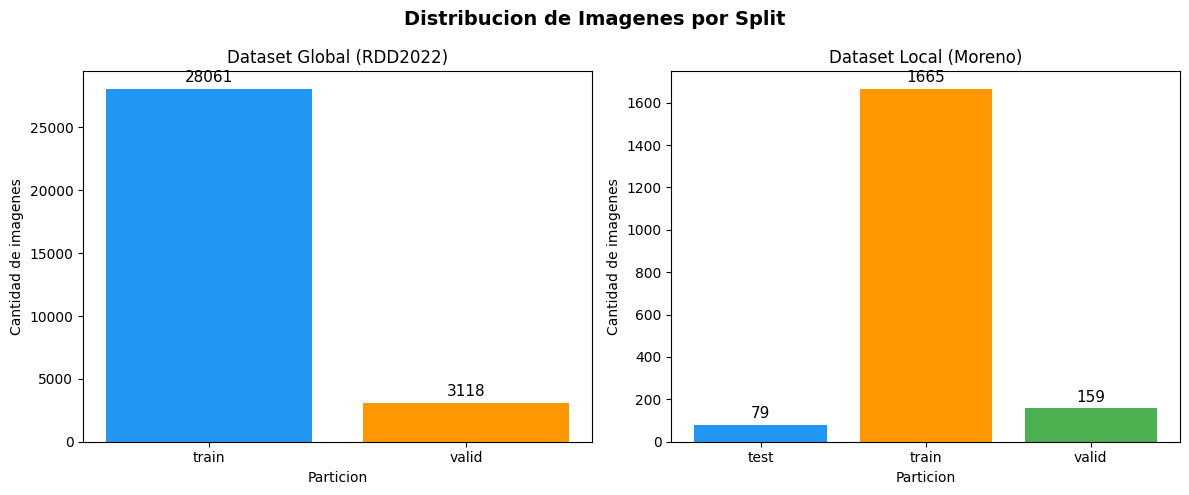

In [22]:
colores_splits = ['#2196F3', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribucion de Imagenes por Split', fontsize=14, fontweight='bold')

for ax, (splits, titulo) in zip(axes, [
    (splits_global, 'Dataset Global (RDD2022)'),
    (splits_local,  'Dataset Local (Moreno)')
]):
    etiquetas = list(splits.keys())
    valores   = list(splits.values())
    barras = ax.bar(etiquetas, valores, color=colores_splits[:len(etiquetas)])
    for barra, val in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + max(valores) * 0.01,
                str(val), ha='center', va='bottom', fontsize=11)
    ax.set_title(titulo)
    ax.set_ylabel('Cantidad de imagenes')
    ax.set_xlabel('Particion')

plt.tight_layout()
plt.show()

El modelo dispondrá de 29.726 imágenes de entrenamiento, 3.277 de validación y 79 de test, lo cual representa una base sólida para el proceso de ajuste y evaluación.

<!-- ## 13. Imágenes -->

## 12. Mapa de Calor de Posición Central de las Boxes

Se construye un mapa de calor bidimensional que muestra dónde se concentran los centros de las bounding boxes dentro del espacio normalizado de la imagen.

In [23]:
def extraer_centros(ruta_base, splits):
    centros_x, centros_y = [], []
    for split in splits:
        patron = os.path.join(ruta_base, split, 'labels', '*.txt')
        for ruta_txt in glob.glob(patron):
            with open(ruta_txt, 'r') as f:
                for linea in f:
                    partes = linea.strip().split()
                    if len(partes) == 5:
                        centros_x.append(float(partes[1]))
                        centros_y.append(float(partes[2]))
    return centros_x, centros_y

cx_global, cy_global = extraer_centros(ruta_processed_global, ['train', 'valid'])
cx_local,  cy_local  = extraer_centros(ruta_processed_local,  ['train', 'valid', 'test'])

print(f'Total de centros extraidos — Global: {len(cx_global)} | Local: {len(cx_local)}')

Total de centros extraidos — Global: 15813 | Local: 807


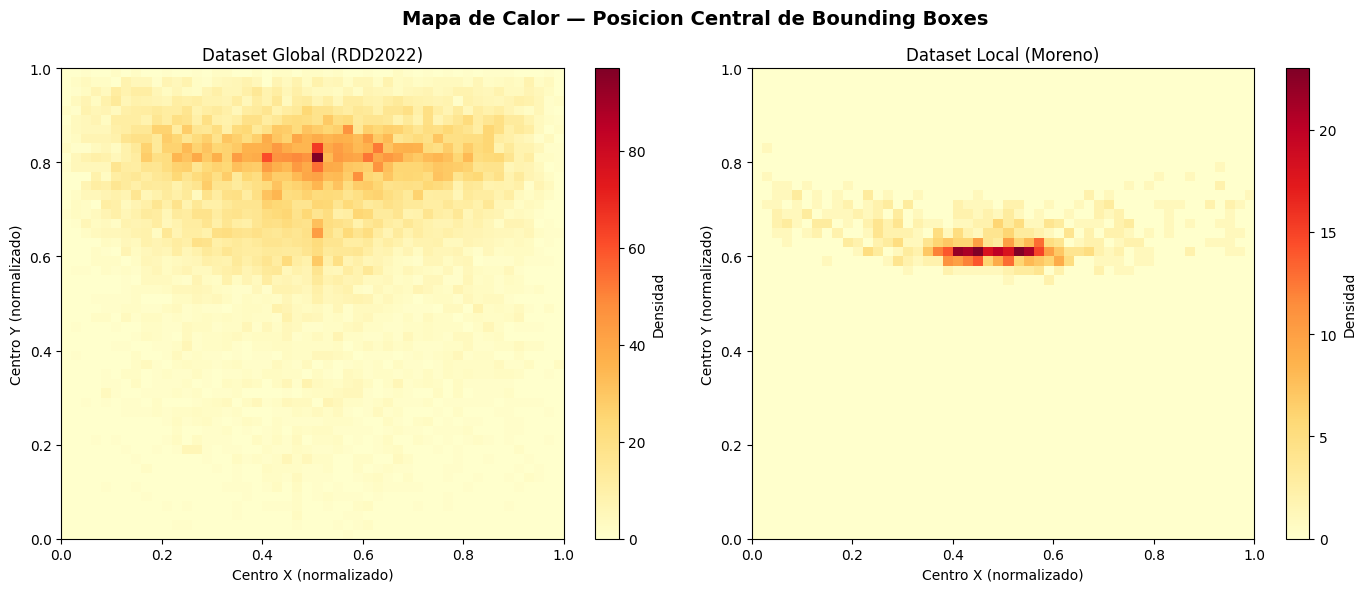

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Mapa de Calor — Posicion Central de Bounding Boxes', fontsize=14, fontweight='bold')

for ax, (cx, cy, titulo) in zip(axes, [
    (cx_global, cy_global, 'Dataset Global (RDD2022)'),
    (cx_local,  cy_local,  'Dataset Local (Moreno)')
]):
    heatmap, xedges, yedges = np.histogram2d(cx, cy, bins=50, range=[[0, 1], [0, 1]])
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    im = ax.imshow(heatmap.T, extent=extent, origin='lower', cmap='YlOrRd', aspect='auto')
    plt.colorbar(im, ax=ax, label='Densidad')
    ax.set_title(titulo)
    ax.set_xlabel('Centro X (normalizado)')
    ax.set_ylabel('Centro Y (normalizado)')

plt.tight_layout()
plt.show()

Dataset Global (RDD2022): La concentración se ubica en la franja Y ≈ 0.75–0.85. Esto es consistente con capturas desde el tablero de un vehículo con cámara fija apuntando hacia adelante: el asfalto ocupa naturalmente la parte baja del encuadre.


Dataset Local (Moreno): La concentración aparece más arriba, en Y ≈ 0.60, y forma una banda horizontal más estrecha y definida. Esto se explica por la forma en que se capturaron los videos locales: el teléfono apoyado en el tablero encuadra el asfalto en una franja más acotada del centro-inferior de la imagen.


## 13. Resumen de Estadísticas

Se genera un resumen unificado con las métricas clave extraídas durante todo el análisis exploratorio. Este cuadro sirve como referencia cuantitativa para la toma de decisiones en la etapa de entrenamiento del modelo.

In [25]:
filas_resumen = []

for dataset_nombre, df_box, df_img in [
    ('Global (RDD2022)', df_box_global, df_img_global),
    ('Local (Moreno)',   df_box_local,  df_img_local)
]:
    total_insts = len(df_box)
    for cid, nombre_clase in mapa_clases.items():
        subset = df_box[df_box['clase_id'] == cid]
        if subset.empty:
            continue
        filas_resumen.append({
            'Dataset':            dataset_nombre,
            'Clase':              nombre_clase,
            'Instancias':         len(subset),
            '% del total':        f"{len(subset) / total_insts * 100:.1f}%",
            'Ancho medio':        f"{subset['bbox_width'].mean():.4f}",
            'Alto medio':         f"{subset['bbox_height'].mean():.4f}",
            'Aspect Ratio medio': f"{subset['aspect_ratio'].mean():.3f}",
        })

df_resumen = pd.DataFrame(filas_resumen)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
display(df_resumen)

,Dataset,Clase,Instancias,% del total,Ancho medio,Alto medio,Aspect Ratio medio
0,Global (RDD2022),D20 (Piel de Cocodrilo),9490,60.0%,0.3989,0.2637,1.668
1,Global (RDD2022),D40 (Bache),6323,40.0%,0.1284,0.0787,1.747
2,Local (Moreno),D20 (Piel de Cocodrilo),167,20.7%,0.1286,0.0604,2.384
3,Local (Moreno),D40 (Bache),227,28.1%,0.0997,0.0398,2.761
4,Local (Moreno),calle_tierra,413,51.2%,0.6643,0.1947,3.522


Tamaño de las cajas: Las instancias del dataset global son considerablemente más grandes en promedio (ancho medio 0.39 para D20 global vs 0.13 para D20 local). Esto se debe a que las cámaras del RDD2022 capturan desde distancias y ángulos distintos a los datos locales, donde el teléfono apoyado en el tablero genera un encuadre más cerrado sobre el asfalto.

Aspect ratio: Todas las clases presentan un aspect ratio mayor a 1, confirmando que las cajas son más anchas que altas. El caso más extremo es calle_tierra (3.52), lo cual es geométricamente coherente: una franja de tierra sin pavimentar tiende a ocupar todo el ancho del carril pero poca altura en la imagen.

Desbalance: En el dataset global D20 representa el 60% de las instancias vs 40% de D40. En el local la clase dominante es calle_tierra con 51.2%, seguida de D40 (28.1%) y D20 (20.7%). Esta inversión de proporciones entre datasets refuerza la importancia de no fusionarlos sin control durante el entrenamiento.

## 14. Data Augmentation del Dataset Local

El Dataset Local fue exportado desde Roboflow con una configuración de preprocesamiento y aumento de datos aplicada sobre las imágenes originales.

La configuración aplicada fue la siguiente:

* **Preprocesamiento:**
  *  — corrige automáticamente la orientación de la imagen
  *  — redimensiona manteniendo el aspecto original y rellena con bordes negros

* **Aumentos aplicados:**
  *  — espejado horizontal para simular distintos carriles de circulación.
  *  — recortes aleatorios para simular variaciones de distancia al daño.
  *  — rotaciones leves para compensar la inclinación natural del teléfono.
  *  — variaciones de iluminación para robustecer el modelo ante distintas condiciones de luz solar.
  *  — difuminado leve que simula vibraciones del vehículo durante la captura.

Gracias a esta estrategia, el dataset local pasó de aproximadamente **800 imágenes originales** a casi **1900 imágenes de entrenamiento**.

In [ ]:
# Estimacion del volumen original vs aumentado
imgs_train_local = splits_local.get("train", 0)
imgs_valid_local = splits_local.get("valid", 0)
imgs_test_local  = splits_local.get("test", 0)

FACTOR_AUGMENTATION = 3

originales_estimadas_train = round(imgs_train_local / FACTOR_AUGMENTATION)
total_original_estimado    = originales_estimadas_train + imgs_valid_local + imgs_test_local
total_con_augmentation     = imgs_train_local + imgs_valid_local + imgs_test_local

print("--- Estimacion de impacto del Data Augmentation ---")
print(f"  Imagenes de entrenamiento (con augmentation x{FACTOR_AUGMENTATION}): {imgs_train_local}")
print(f"  Imagenes originales estimadas en train:                          {originales_estimadas_train}")
print(f"  Imagenes de validacion (sin augmentation):                       {imgs_valid_local}")
print(f"  Imagenes de test (sin augmentation):                             {imgs_test_local}")
print()
print(f"  Total estimado SIN augmentation: {total_original_estimado} imagenes")
print(f"  Total real   CON augmentation:   {total_con_augmentation} imagenes")
print(f"  Incremento efectivo:             {(total_con_augmentation / total_original_estimado - 1) * 100:.1f}%")

--- Estimacion de impacto del Data Augmentation ---
  Imagenes de entrenamiento (con augmentation x3): 1665
  Imagenes originales estimadas en train:                          555
  Imagenes de validacion (sin augmentation):                       159
  Imagenes de test (sin augmentation):                             79

  Total estimado SIN augmentation: 793 imagenes
  Total real   CON augmentation:   1903 imagenes
  Incremento efectivo:             140.0%


## 15. Conclusiones

En conclusión, luego de analizar los diferentes apartados del análisis exploratorio observamos que:

* **Desbalance de clases:** El dataset global presenta una proporción dominante de instancias `D20` (60%) respecto a `D40` (40%). En el dataset local la situación se invierte: `calle_tierra` domina con el 51%, seguida de `D40` (28%) y `D20` (21%), lo que refleja la realidad territorial del municipio de Moreno donde una parte significativa de las calles no están asfaltadas. Este desbalance diferencial entre fuentes refuerza la necesidad de monitorear las métricas por clase (precisión y recall individuales) durante el entrenamiento para detectar si alguna clase está siendo sistemáticamente ignorada por el modelo.

* **Geometría de las boxes:** Las bounding boxes presentan tamaños notablemente distintos entre datasets. En el global las cajas son considerablemente más grandes (ancho medio 0.40) que en el local (0.13), debido a diferencias en el ángulo y distancia de captura entre las cámaras del RDD2022 y el teléfono apoyado en el tablero. En ambos casos el aspect ratio supera 1.0, indicando que las cajas son más anchas que altas, consistente con la perspectiva desde el tablero donde el asfalto se ve en ángulo. El caso más extremo es `calle_tierra` (aspect ratio 3.52), geométricamente coherente con una franja que ocupa todo el ancho del carril pero poca altura en la imagen.

* **Objetos pequeños a medianos:** El área mediana de las bounding boxes es de apenas 0.033, es decir que la caja típica ocupa solo el 3.3% de la imagen total. Esto clasifica el problema como detección de objetos pequeños a medianos, uno de los escenarios más desafiantes para modelos de detección en general, ya que las características visuales disponibles para discriminar el objeto son escasas. Este hallazgo justifica el uso de resoluciones de entrada de 640×640.

* **Imágenes de fondo:** La presencia de imágenes sin anotaciones (`background images`) es intencional y necesaria para que el modelo aprenda a distinguir calles en buen estado y no genere falsas detecciones sobre superficies sanas. Representan aproximadamente el 69% del dataset global y el 62% del local, proporciones que reflejan la realidad: la mayor parte del recorrido de inspección transcurre sobre calles sin daños visibles. Su proporción debe mantenerse controlada durante el entrenamiento para no afectar el recall del modelo: un exceso de negativos puede hacer que el modelo sea demasiado conservador y no detecte daños reales, mientras que su ausencia genera modelos propensos a falsos positivos.

* **Distribución espacial:** El mapa de calor evidencia que los daños se concentran en franjas horizontales bien definidas: Y ≈ 0.80 en el dataset global e Y ≈ 0.60 en el local. La diferencia en la posición vertical entre datasets se explica por la altura y ángulo de montaje del dispositivo de captura.

* **Densidad de anotaciones:** La distribución de boxes por imagen está fuertemente sesgada: la mediana es 0 y la media apenas supera 0.5, confirmando que las escenas con múltiples daños simultáneos son la excepción y no la regla. Las imágenes con 10 o más boxes provienen casi exclusivamente del dataset global, particularmente de India y Norway, donde los tramos capturados muestran deterioro severo.

* **Representatividad del split:** La partición 90/10 aplicada al dataset global con semilla fija (`random.seed(42)`) y la estructura provista por Roboflow para el dataset local generan conjuntos de validación suficientemente representativos para evaluar el modelo durante el entrenamiento. En total el modelo dispondrá de 29.726 imágenes de entrenamiento, 3.277 de validación y 79 de test. La semilla fija garantiza la reproducibilidad del experimento, de modo que cualquier miembro del equipo que re-ejecute el pipeline obtendrá exactamente la misma partición.

* **Complementariedad de los datasets:** El análisis conjunto confirma que ambos datasets son estructuralmente distintos. El dataset global aporta volumen masivo, variedad geográfica (India, Japón, Noruega, República Checa) y robustez ante condiciones de captura diversas, entrenando al modelo en la detección de daños bajo distintas condiciones de iluminación, tipo de asfalto y calidad de cámara. El dataset local aporta el contexto territorial específico del municipio de Moreno: la textura característica del asfalto de la Zona Oeste, las condiciones de iluminación del Gran Buenos Aires y, fundamentalmente, la clase `calle_tierra` que no existe en el RDD2022 y es indispensable para evitar falsos positivos en producción sobre las numerosas calles sin pavimentar del partido. La combinación de ambas fuentes en el entrenamiento es lo que hace al sistema viable para su despliegue real.

* **Data Augmentation:** La estrategia de aumento configurada en Roboflow (flip, crop, rotación, brillo y blur) permitió duplicar el volumen de imágenes de entrenamiento del dataset local, pasando de ~800 imágenes originales a ~1900 efectivas.